# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
### Assignment Notebook: **AI-Powered Customer Review Insights Pipeline**

## Objective

Build an Automation pipeline that processes customer reviews for the *XSound Pro Headphones* (or any other product), then performs summarization, sentiment analysis, summary tone classification, exports the results to Excel sheet for ongoing trend monitoring and internal product feedback analysis, and if the review is negative send the insights to the team lead.

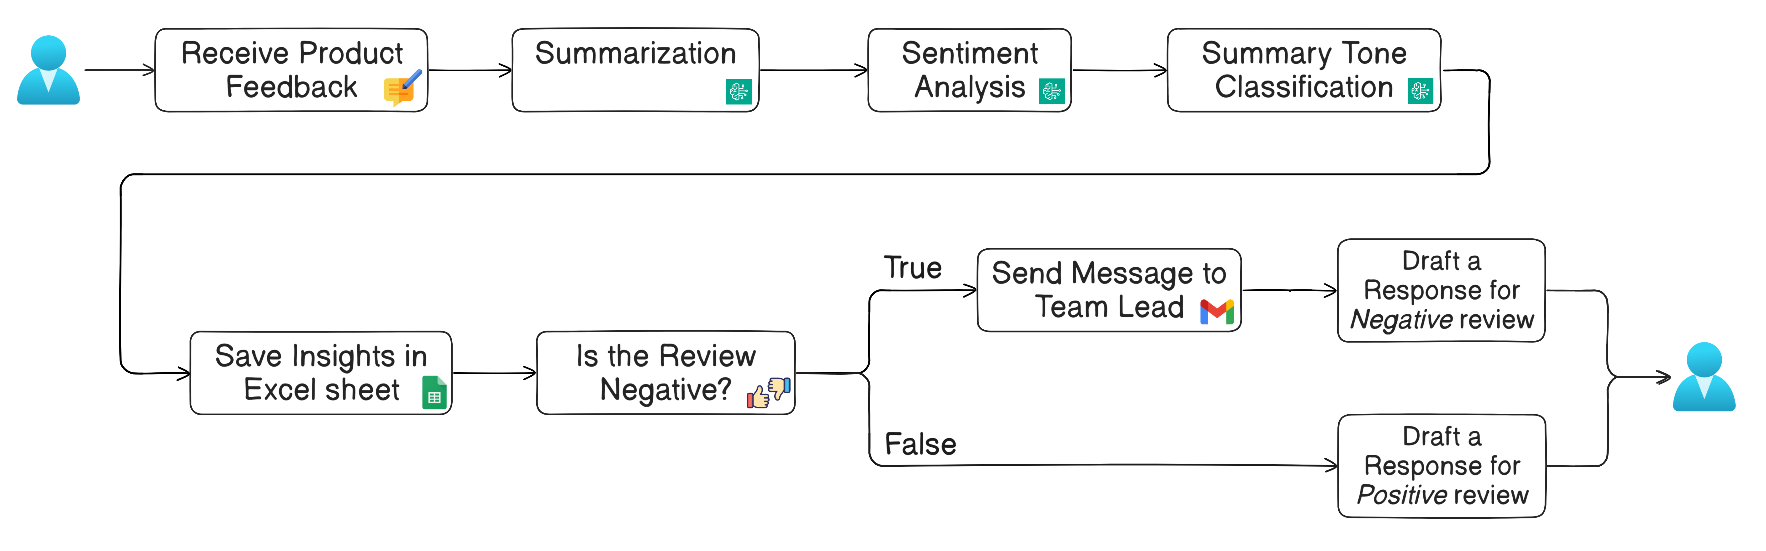

## Problem Statement

For an online consumer electronics brand selling headphones, monitoring customer feedback is crucial for improving product quality, marketing strategies, and customer satisfaction.  

Manually reviewing hundreds of customer reviews is **time-consuming**, often **inconsistent**, and prone to human bias.  

Key challenges include:

- Identifying **core feedback themes** hidden in lengthy or subjective reviews.  
- Evaluating **overall sentiment trends** for quick decision-making.  
- Providing **actionable summaries** to marketing, product, and support teams in a timely manner.

An **automated AI-powered review analysis pipeline** can solve these challenges by:

- Reducing processing time from hours to minutes.  
- Ensuring consistent sentiment and tone detection across all reviews.  
- Delivering structured summaries and sentiment scores directly to a centralized platform like Google Sheets.  

This experiment should solve the above problem by using **LangChain** to build a Generative AI application that leverages LLMs for generating Product Review Summaries from user-entered Product Name and Product Review.  



### Use Case Scenario

The sales team of an organization needs a streamlined way to analyze customer product reviews and quickly understand key insights without manual processing. Currently, generating concise review summaries, identifying sentiment, and detecting tone are manual and time-consuming tasks. This slows down follow-ups with customers and limits timely feedback to internal stakeholders.  

To address this, you will need to implement a LangChain pipeline that should be able to:

- Accept user-entered **Product Name** and **Product Review**  
- Generate a **Product Review Summary** using an LLM like from OpenAI models, or Mistral Cloud Chat models  
- Extract both the **Sentiment** of the review and the **Tone** of the generated summary  
- Calculate confidence scores for sentiment and tone  
- Log all results (including scores) into an Excel Sheet for internal sales team's reference
- Automatically send email message if the customer review is negative with the product name and AI-generated summary

### Setup Steps:

In [ ]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "" #@param {type:"string"}

In [ ]:
#@title Please enter your password (your registered phone number) to continue: { run: "auto", display-mode: "form" }
password = "" #@param {type:"string"}

In [ ]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython
from IPython.display import HTML, display

ipython = get_ipython()

notebook= "M4_AST_01_AI-Powered_Customer_Review_Insights_Pipeline"   #name of the notebook

batchId = "IISC-AC-GENAI-02"


def print_message(message: str, color: str = "red"):
    display(HTML(f"<span style='color:{color};'>{message}</span>"))

def setup():
#  ipython.magic("sx pip3 install torch")

    from IPython.display import HTML, display
    display(HTML('<script src="https://dashboard.talentsprint.com/submissions/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():
    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword(), "batch" : batchId}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print_message(r["err"])
        return None
      else:
        print_message("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getAnswer() and getComplexity() and getAdditional() and getConcepts() and getComments() and getMentorSupport():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "answer" : Answer, "id" : Id, "file_hash" : file_hash,
              "notebook" : notebook,
              "feedback_experiments_input" : Comments,
              "feedback_mentor_support": Mentor_support,
              "batch" : batchId
            }
      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iisc.talentsprint.com/notebook_submissions")
        #print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
        return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None


# def getWalkthrough():
#   try:
#     if not Walkthrough:
#       raise NameError
#     else:
#       return Walkthrough
#   except NameError:
#     print ("Please answer Walkthrough Question")
#     return None

def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None


def getMentorSupport():
  try:
    if not Mentor_support:
      raise NameError
    else:
      return Mentor_support
  except NameError:
    print ("Please answer Mentor support Question")
    return None

def getAnswer():
  try:
    if not Answer:
      raise NameError
    else:
      return Answer
  except NameError:
    print ("Please answer Question")
    return None


def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()
else:
  print ("Please complete Id and Password cells before running setup")

### Install Required Libraries

In [ ]:
%%capture
!pip -q install groq==0.37.1
!pip -q install langchain-groq==1.1.2
!pip -q install langchain==1.2.12
!pip -q install langchain-core==1.2.19
!pip -q install langchain_community==0.4.1

### Read the Groq API Key

Using the Groq API Key, you will have access to the OpenAI and Llama model, free of cost, under the [Free-tier](https://console.groq.com/docs/rate-limits#rate-limits).

This cell retrieves the Groq API key securely stored in Google Colab's Secrets (see 'key' icon on the leftmost panel of this notebook) and sets it as an environment variable `GROQ_API_KEY`. This is a recommended practice to avoid exposing your API key directly in the code.


* Go to https://console.groq.com/, and setup a Free account.

* Create a new API by visiting: https://console.groq.com/keys

* Save the key in Google Colab's Secrets
    ```
    Secret Name: GROQ_API_KEY
    Secret Value: Paste your Groq api key
    ```

* Read the key and save as an environment variable `GROQ_API_KEY`

In [ ]:
# Save the key in Colab's Secrets then load from there

import os
from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

**Initialize a Chat Model**

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)

In [ ]:
response = llm.invoke("What is 2 plus 3")

print(response.content)

## **Summarization**

Perform summarization for the Product Review submitted. (Output should only be the summary text)

In [ ]:
summarization_prompt = """
You are an expert product analyst.

Your task is to read the customer product review and generate a concise, clear summary.

Instructions:
- Capture the key points of the review.
- Include both positive and negative aspects if present.
- Keep the summary short (2–3 sentences maximum).
- Do not add any new information.
- Do not include explanations, labels, or formatting.

Output:
Return only the summary text.

Product Name: {product_name}
Product Review: {product_review}
"""

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

summarization_template = ChatPromptTemplate.from_template(summarization_prompt)
summarization_template

In [ ]:
review1 = """
I’ve been using these Headphones for about two weeks now, and overall I’m quite impressed.
The sound quality is excellent with deep bass and clear vocals, making it great for both music and calls.
The noise cancellation works well in moderately noisy environments, though it struggles a bit in very loud places.
The battery life is solid and easily lasts a full day of use.
However, the ear cushions start to feel slightly uncomfortable after long hours, and
the build quality could be a bit more premium for the price.
Still, it’s a good value for money option."
"""

In [ ]:
print(summarization_template.invoke(
    {"product_name": "XSound Pro Headphones",
     "product_review": review1}
    ).messages[0].content)

In [ ]:
# Initialize Output parser

from langchain_core.output_parsers import StrOutputParser

str_parser = StrOutputParser()

In [ ]:
# Create Summarization Chain

summarization_chain = summarization_template | llm | str_parser

In [ ]:
# Execute Chain

summary = summarization_chain.invoke(
    {"product_name": "XSound Pro Headphones",
     "product_review": review1}
)

summary

## **Sentiment Analysis**

Analyse the sentiment (Positive/Negative/Neutral) of the Product Review submitted.

Output should be in this format:

    Sentiment: <Positive/Negative/Neutral> | Score: <numeric value between 0 and 1>

In [ ]:
sentiment_prompt = """
You are a sentiment analysis expert.

Your task is to analyze the sentiment of the given product review.

Instructions:
- Classify the sentiment as one of the following: Positive, Negative, or Neutral.
- Assign a confidence score between 0 and 1 (e.g., 0.85).
- Base your decision only on the content of the review.
- Do not include any explanation or additional text.

Output Format:
Sentiment: <Positive/Negative/Neutral> | Score: <numeric value between 0 and 1>

Product Review:
{product_review}
"""

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

sentiment_template = ChatPromptTemplate.from_template(sentiment_prompt)
sentiment_template

In [ ]:
print(sentiment_template.invoke(
    {"product_review": review1}
    ).messages[0].content)

In [ ]:
# Create Sentiment Analysis Chain

sentiment_chain = sentiment_template | llm | str_parser

In [ ]:
# Execute Chain

sentiment = sentiment_chain.invoke(
    {"product_review": review1}
)

sentiment

## **Summary Tone Classification**

Classify the tone (Informative/Persuasive/Friendly) of the Product Review Summary generated during Summarization step.

Output should be in this format:

    Tone: <Informative/Persuasive/Friendly> | Score: <numeric value between 0 and 1>


In [ ]:
tone_clf_prompt = """
You are an expert in text tone analysis.

Your task is to classify the tone of the given product review summary.

Instructions:
- Classify the tone as one of the following:
  Informative, Persuasive, or Friendly.
- Assign a confidence score between 0 and 1 (e.g., 0.82).
- Base your decision only on the given summary.
- Do not include any explanation or additional text.

Output Format:
Tone: <Informative/Persuasive/Friendly> | Score: <numeric value between 0 and 1>

Product Review Summary:
{review_summary}
"""

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

tone_clf_template = ChatPromptTemplate.from_template(tone_clf_prompt)
tone_clf_template

In [ ]:
print(tone_clf_template.invoke(
    {"review_summary": summary}
    ).messages[0].content)

In [ ]:
# Create Tone Classification Chain

tone_clf_chain = tone_clf_template | llm | str_parser

In [ ]:
# Execute Chain

tone = tone_clf_chain.invoke(
    {"review_summary": summary}
)

tone

## **Save Insights in the Excel Sheet**

In [ ]:
import pandas as pd
import os

FILENAME = "Customer_Review_Insights.xlsx"

product_name = "XSound Pro Headphones"
product_review = review1        # Using the review1 variable defined earlier

def save_to_excel(product_name, product_review, summary, sentiment, tone, filename=FILENAME):
    # Prepare the data for the new row
    new_row_data = {
        "Product Name": [product_name],
        "Product Review": [product_review],
        "Product Review Summary": [summary],
        "Sentiment and Score": [sentiment],
        "Tone and Score": [tone]
    }
    new_df = pd.DataFrame(new_row_data)

    # Check if the file exists
    if os.path.exists(filename):
        # If it exists, load the existing data and append the new row
        existing_df = pd.read_excel(filename)
        updated_df = pd.concat([existing_df, new_df], ignore_index=True)
    else:
        # If it doesn't exist, the new_df is the first DataFrame
        updated_df = new_df

    # Save the DataFrame to Excel
    updated_df.to_excel(filename, index=False)
    print(f"Insights saved to `{filename}` successfully!")


In [ ]:
# Execute the function to save insights
save_to_excel(
    product_name=product_name,
    product_review=product_review,
    summary=summary,
    sentiment=sentiment,
    tone=tone
)

In [ ]:
#@title Run this cell to check the Data stored in the Excel Sheet

import pandas as pd

pd.set_option('display.max_colwidth', None)

# Check if the file exists
if os.path.exists(FILENAME):
    # If it exists, load the existing data and append the new row
    df = pd.read_excel(FILENAME)
else:
    df = "File doesn't exist!"

print(FILENAME)
df

## **Send Email Message for Negative Reviews**

- Add the condition to check if the sentiment of the Product review is Negative or not.

- If the review is Negative, send an email message to the Team Lead with following details:  
  - **Send To:** \<Provide your email\>  
  - **Subject:** Negative Customer Review Received – \<Product-Name\>
  - **Message:**  
    ```
    Dear Team Lead

    We have received a negative customer review for the product - <Product-Name>.  
    Please find the feedback summary below:  
    <Product Review Summary>

    Best Regards,
    Automation Team
    ```

#### How to Send Email using Python?

To send an email message programatically using Python, we need to use App Password.

**How to create and use an App Password?**

An app password is a 16-digit passcode that gives a less secure app or device permission to access your Google Account.

**Note:** App passwords can only be used with Google accounts that have 2-Step Verification turned on.

**To get your account App Password,**

1. Go to your Google Account.
2. Select Security.
3. In the search bar, search for App passwords.
4. Enter a name that helps you remember where you’ll use the app password.
5. Select Generate.
6. Copy the generated app password. Remove spaces in between, it is a 16-character code.
7. Select Done.

If you’ve set up 2-Step Verification but can’t find the option to add an app password, it might be because:

1. Your Google Account has 2-Step Verification set up only for security keys.
2. You’re logged into a work, school, or another organization account.
3. Your Google Account has Advanced Protection.


In [ ]:
# Standard library for sending email using the Simple Mail Transfer Protocol (SMTP)
import smtplib

# Classes for creating email content and multi-part (e.g., text + attachments) messages
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

# Utility to format the “From” header with a display name plus email address
from email.utils import formataddr

In [ ]:
SENDER_EMAIL = "yrajm1997@gmail.com"      # <------- REPLACE with your own email address
RECEIVER_EMAIL = "yrajm1997@gmail.com"    # <------- REPLACE with your own email address
APP_PASSWORD = "ttjzgklkwuafohzp"         # <------- REPLACE with your app password

In [ ]:
# Function to send Email

def send_email(receiver_email, subject, body):
    """
    Send a plain-text email using Gmail's SMTP server.

    Parameters:
        receiver_email (str): Recipient's email address
        subject (str): Subject line of the email
        body (str): Message body (plain text)
    """

    # ---- SMTP Configuration ----
    smtp_server = "smtp.gmail.com"        # Gmail SMTP server
    smtp_port = 587                       # Port for TLS encryption
    sender_name = "Support Team"          # Display name that appears to the recipient
    sender_email = SENDER_EMAIL
    app_password = APP_PASSWORD

    # ---- Compose the Email ----
    message = MIMEMultipart()                                 # Create a multi-part email container
    message["From"] = formataddr((sender_name, sender_email)) # Add sender name + email
    message["To"] = receiver_email                            # Add recipient address
    message["Subject"] = subject                              # Add subject line
    message.attach(MIMEText(body, "plain"))                   # Attach the email body as plain text

    # ---- Send the Email ----
    try:
        # Connect to the SMTP server and secure the connection
        with smtplib.SMTP(smtp_server, smtp_port) as server:
            server.starttls()                                                   # Start TLS encryption for security
            server.login(sender_email, app_password)                                # Log in using the sender's credentials
            server.sendmail(sender_email, receiver_email, message.as_string())  # Send the email
        return "Email sent successfully!"
    except Exception as e:
        # Print and return an error message if sending fails
        print(f"Error sending message: {e}")
        return "Email could not be delivered!"


In [ ]:
# Test the function

send_email(
    receiver_email=RECEIVER_EMAIL,
    subject = "Test Email",
    body = "This is a test email sent using Python."
    )

In [ ]:
# Function to Send Alert Notification

def send_alert_notification(product_name, product_review, summary, sentiment, tone):
    """
    Send an alert notification if the sentiment of the product review is negative.
    """

    # Check if the sentiment is negative
    if "Negative" in sentiment:
        send_email(
            receiver_email=RECEIVER_EMAIL,
            subject=f"Negative Customer Review Received – {product_name}",
            body=f"""
            Dear Team Lead

            We have received a negative customer review for the product - {product_name}.
            Please find the feedback summary below:
            {summary}

            Best Regards,
            Automation Team
            """
        )
        print("Received a Negative review. Alert notification sent!")
    else:
        print("Received a Positive/Neutral review. No alert notification sent.")


In [ ]:
# Test the function
send_alert_notification(
    product_name=product_name,
    product_review=product_review,
    summary=summary,
    sentiment=sentiment,
    tone=tone
    )

## **Draft Responses for Positive and Negative Reviews**

In [ ]:
# Define a Jinja Template to draft response

from jinja2 import Template

template_str = """Thank you for taking the time to share your feedback regarding `{{ product_name }}`.

{% if sentiment == "negative" %}
We sincerely apologize for your experience and understand your concerns. Your feedback is extremely valuable to us, and we are actively working to address the issues you’ve highlighted.
Our team would like to investigate this further and ensure a quick resolution.

{% elif sentiment == "positive" %}
We are delighted to hear that you had a great experience and that the product met your expectations.
Your support and appreciation motivate us to continue delivering high-quality products and services.

{% else %}
We appreciate your feedback.

{% endif %}
"""

response_template = Template(template_str)

In [ ]:
# Render the Template for Negative review
output = response_template.render(product_name="XSound Pro Headphones", sentiment="negative")
print(output)

In [ ]:
# Render the Template for Positive review
output = response_template.render(product_name="XSound Pro Headphones", sentiment="positive")
print(output)

## **Complete Pipeline**

All individual components—feedback input, summarization, sentiment analysis, tone classification, saving the insights, alerting and responding—are integrated into a single **Gradio interface**.



***AI-Powered Customer Review Insights Pipeline:***

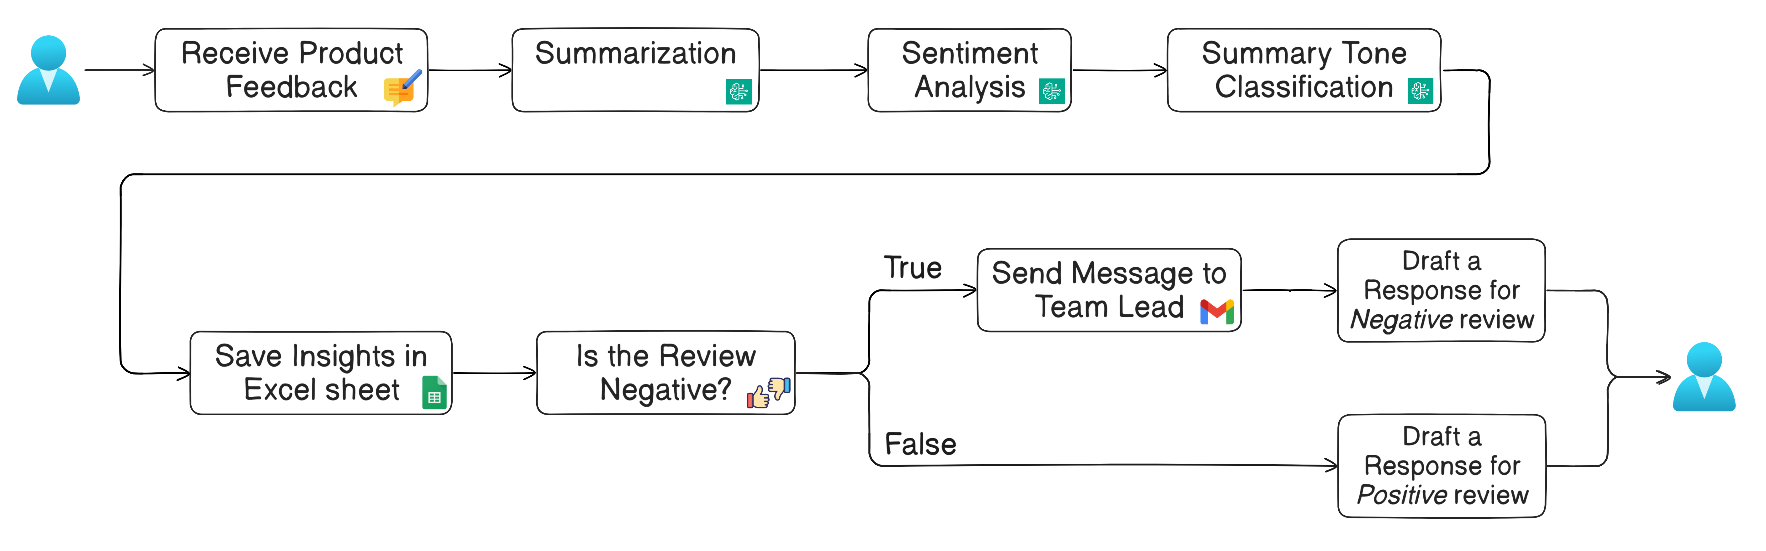

Test the pipeline on the sample reviews given below for *XSound Pro Headphones*:

- <font color='#002299'>*"I’ve been using the XSound Pro Headphones for a few weeks now, and they have exceeded my expectations. The sound quality is crystal clear, with deep bass and well-balanced audio. The battery life easily lasts more than a full day of use. They are also very comfortable to wear for long periods. Overall, I think they offer great value for the price."*</font>

- <font color='#882299'>*"I’m quite disappointed with the XSound Pro Headphones after using them for a few days. The noise cancellation barely works and doesn’t block out background sounds effectively. The audio quality feels flat compared to other brands in the same price range. The build also feels a bit cheap and not very durable. Overall, I don’t think they are worth the money."*</font>

- <font color='#002299'>*"I’ve been using these headphones casually, and they seem decent for everyday use. The sound quality is acceptable but not particularly impressive. Battery life is average and gets me through most of the day. The design is simple and functional without any standout features. Overall, it’s neither great nor bad."*</font>

- <font color='#882299'>*"The sound quality of the XSound Pro is really good, especially for music and videos. I like the clarity and bass performance. However, the ear cushions become uncomfortable after using them for more than an hour. Also, the charging time feels longer than expected. So while the audio is great, comfort could be improved."*</font>


In [ ]:
import gradio as gr

# Input elements for Gradio interface
in_product_name = gr.Textbox(label="Product Name", lines=2)
in_product_review = gr.Textbox(label="Product Review", lines=5)

# Output elements for Gradio interface
out_message = gr.Textbox(label="Message", lines=5)


# Function to get Review Insights
def get_review_insights(product_name, product_review):
    # Summarize the review
    summary = summarization_chain.invoke(
        {"product_name": product_name, "product_review": product_review}
    )
    # Sentiment of the review
    sentiment = sentiment_chain.invoke(
        {"product_review": product_review}
    )
    # Tone of the review
    tone = tone_clf_chain.invoke(
        {"review_summary": summary}
    )
    # Save the insights in the Excel sheet
    save_to_excel(
        product_name=product_name,
        product_review=product_review,
        summary=summary,
        sentiment=sentiment,
        tone=tone
    )
    # If the sentiment is negative, send an email to Team Lead
    if "Negative" in sentiment:
        send_alert_notification(
            product_name=product_name,
            product_review=product_review,
            summary=summary,
            sentiment=sentiment,
            tone=tone
            )
        return response_template.render(product_name=product_name, sentiment="negative")

    return response_template.render(product_name=product_name, sentiment="positive")


In [ ]:
# Sample reviews to test the pipeline

sample_review1 = "I’ve been using the XSound Pro Headphones for a few weeks now, and they have exceeded my expectations. The sound quality is crystal clear, with deep bass and well-balanced audio. The battery life easily lasts more than a full day of use. They are also very comfortable to wear for long periods. Overall, I think they offer great value for the price."
sample_review2 = "I’m quite disappointed with the XSound Pro Headphones after using them for a few days. The noise cancellation barely works and doesn’t block out background sounds effectively. The audio quality feels flat compared to other brands in the same price range. The build also feels a bit cheap and not very durable. Overall, I don’t think they are worth the money."
sample_review3 = "I’ve been using these headphones casually, and they seem decent for everyday use. The sound quality is acceptable but not particularly impressive. Battery life is average and gets me through most of the day. The design is simple and functional without any standout features. Overall, it’s neither great nor bad."
sample_review4 = "The sound quality of the XSound Pro is really good, especially for music and videos. I like the clarity and bass performance. However, the ear cushions become uncomfortable after using them for more than an hour. Also, the charging time feels longer than expected. So while the audio is great, comfort could be improved."

In [ ]:
# Create Gradio Interface
interface = gr.Interface(
    fn=get_review_insights,
    inputs=[in_product_name, in_product_review],
    outputs=out_message,
    title="Customer Review Insights",
    description="Enter product name and review to get insights.",
    examples=[
        ["XSound Pro Headphones", sample_review1],
        ["XSound Pro Headphones", sample_review2],
        ["XSound Pro Headphones", sample_review3],
        ["XSound Pro Headphones", sample_review4]
    ],
    flagging_mode="never",
)

In [ ]:
# Launch the Gradio Interface
interface.launch(debug=True)      # <-- for debugging purpose keep debug=True, keep it False

# NOTE that in the debugging mode, this code cell will keep on running.


In [ ]:
#@title Run this cell to check the Data stored in the Excel Sheet

import pandas as pd

pd.set_option('display.max_colwidth', None)

# Check if the file exists
if os.path.exists(FILENAME):
    # If it exists, load the existing data and append the new row
    df = pd.read_excel(FILENAME)
else:
    df = "File doesn't exist!"

print(FILENAME)
df

### Please answer the questions below to complete the experiment:




In [ ]:
#@title What is the primary purpose of prompt template in LangChain? { run: "auto", form-width: "500px", display-mode: "form" }
Answer = "" #@param ["", "To dynamically generate structured prompts using variables", "To execute API calls to LLMs", "To parse model outputs into JSON"]

In [ ]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]


In [ ]:
#@title If it was too easy, what more would you have liked to be added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "" #@param {type:"string"}


In [ ]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "" #@param ["","Yes", "No"]


In [ ]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [ ]:
#@title Mentor Support: { run: "auto", vertical-output: true, display-mode: "form" }
Mentor_support = "" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [ ]:
#@title Run this cell to submit your notebook for grading { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id = return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")

---

<center>
$END$
</center>

---